**Анализ**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('compr_results.csv')  
svd = df[df['method'] == 'SVD']
jpeg = df[df['method'] == 'JPEG']

**График PSNR от степени сжатия для двух изображений**

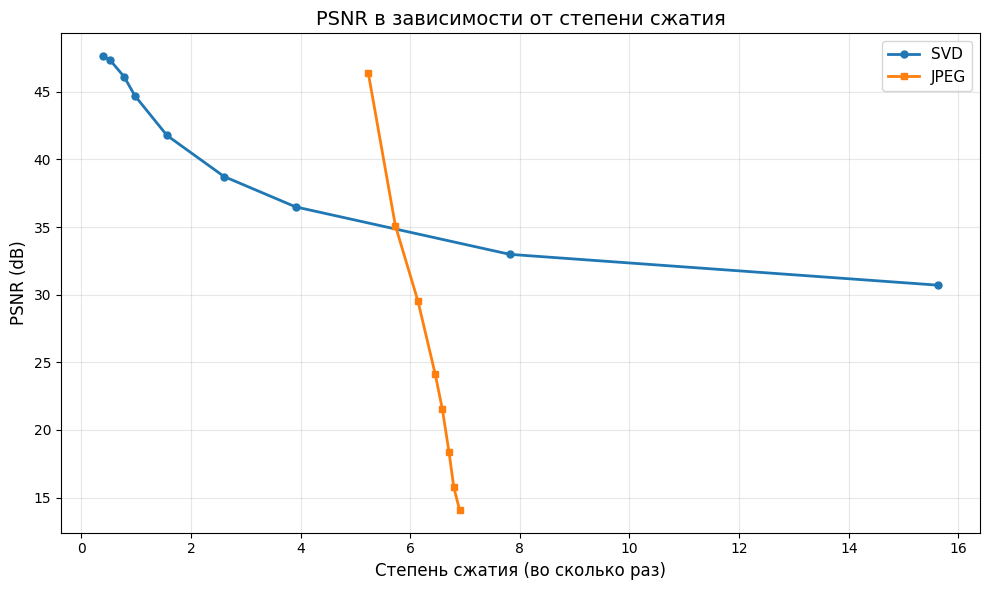

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(svd['compr_ratio'], svd['psnr'], 'o-', label='SVD', linewidth=2, markersize=5)
plt.plot(jpeg['compr_ratio'], jpeg['psnr'], 's-', label='JPEG', linewidth=2, markersize=5)
plt.xlabel('Степень сжатия (во сколько раз)', fontsize=12)
plt.ylabel('PSNR (dB)', fontsize=12)
plt.title('PSNR в зависимости от степени сжатия', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.gca()
plt.tight_layout()
plt.show()

**График SSIM от степени сжатия для двух изображений**

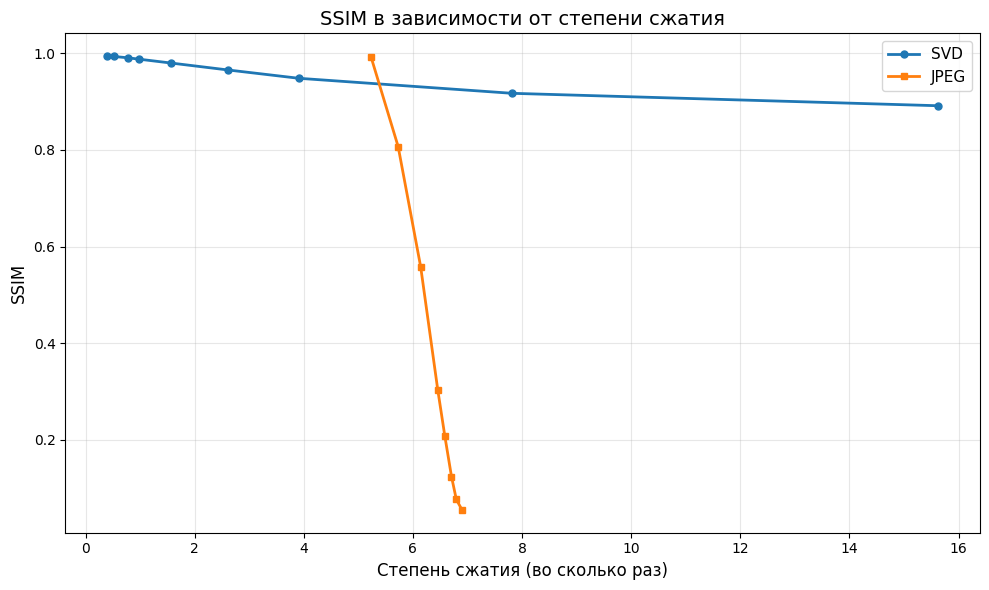

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(svd['compr_ratio'], svd['ssim'], 'o-', label='SVD', linewidth=2, markersize=5)
plt.plot(jpeg['compr_ratio'], jpeg['ssim'], 's-', label='JPEG', linewidth=2, markersize=5)
plt.xlabel('Степень сжатия (во сколько раз)', fontsize=12)
plt.ylabel('SSIM', fontsize=12)
plt.title('SSIM в зависимости от степени сжатия', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.gca()
plt.tight_layout()
plt.show()

**График PSNR от параметра (k/quality)**

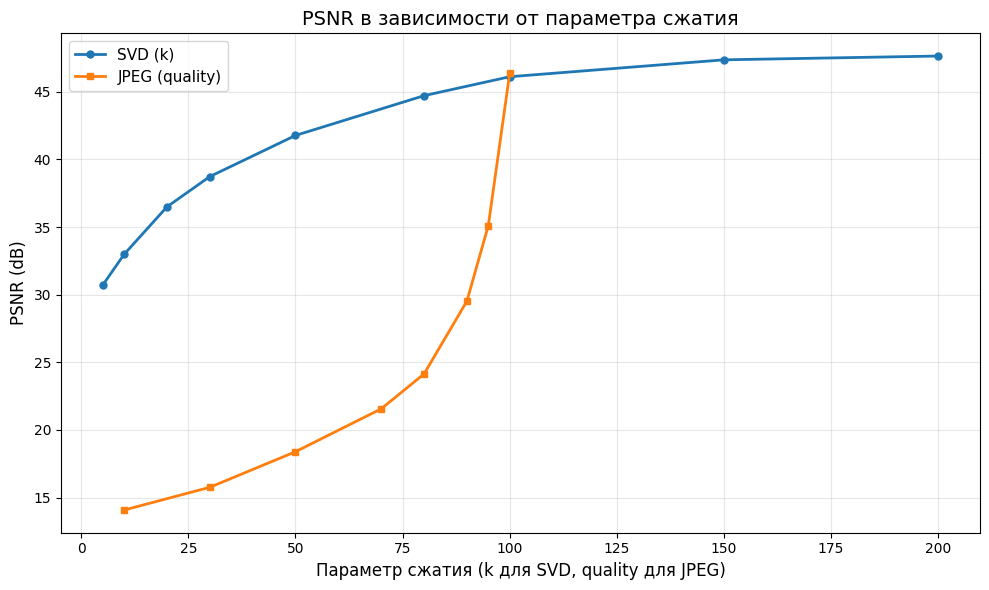

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(svd['param_val'], svd['psnr'], 'o-', label='SVD (k)', linewidth=2, markersize=5)
plt.plot(jpeg['param_val'], jpeg['psnr'], 's-', label='JPEG (quality)', linewidth=2, markersize=5)
plt.xlabel('Параметр сжатия (k для SVD, quality для JPEG)', fontsize=12)
plt.ylabel('PSNR (dB)', fontsize=12)
plt.title('PSNR в зависимости от параметра сжатия', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**График времени выполнения**

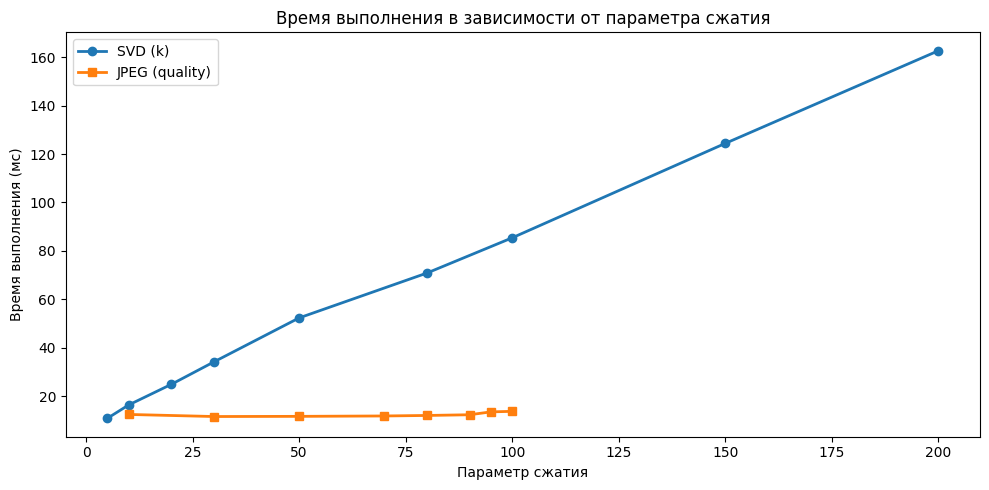

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(svd['param_val'], svd['time'], 'o-', label='SVD (k)', linewidth=2, markersize=6)
plt.plot(jpeg['param_val'], jpeg['time'], 's-', label='JPEG (quality)', linewidth=2, markersize=6)
plt.xlabel('Параметр сжатия')
plt.ylabel('Время выполнения (мс)')
plt.title('Время выполнения в зависимости от параметра сжатия')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
print("Сравнительный анализ")


print("\nЛучшее качество (максимальный PSNR):")
print(f"  SVD:  {svd['psnr'].max():.2f} dB (k={svd.loc[svd['psnr'].idxmax(), 'param_val']:.0f})")
print(f"  JPEG: {jpeg['psnr'].max():.2f} dB (quality={jpeg.loc[jpeg['psnr'].idxmax(), 'param_val']:.0f})")

print("\nЛучшее сжатие (максимальная степень сжатия):")
print(f"   SVD:  {svd['compr_ratio'].max():.2f}x (k={svd.loc[svd['compr_ratio'].idxmin(), 'param_val']:.0f})")
print(f"   JPEG: {jpeg['compr_ratio'].max():.2f}x (quality={jpeg.loc[jpeg['compr_ratio'].idxmin(), 'param_val']:.0f})")

print("\nСреднее время выполнения:")
print(f"   SVD:  {svd['time'].mean():.2f} мс")
print(f"   JPEG: {jpeg['time'].mean():.2f} мс")
print(f"   JPEG быстрее в {svd['time'].mean()/jpeg['time'].mean():.1f} раза")

Сравнительный анализ

Лучшее качество (максимальный PSNR):
  SVD:  47.64 dB (k=200)
  JPEG: 46.39 dB (quality=100)

Лучшее сжатие (максимальная степень сжатия):
   SVD:  15.63x (k=200)
   JPEG: 6.90x (quality=100)

Среднее время выполнения:
   SVD:  64.67 мс
   JPEG: 12.42 мс
   JPEG быстрее в 5.2 раза


**Примеры восстановленнных изобр. при разных k и quality**

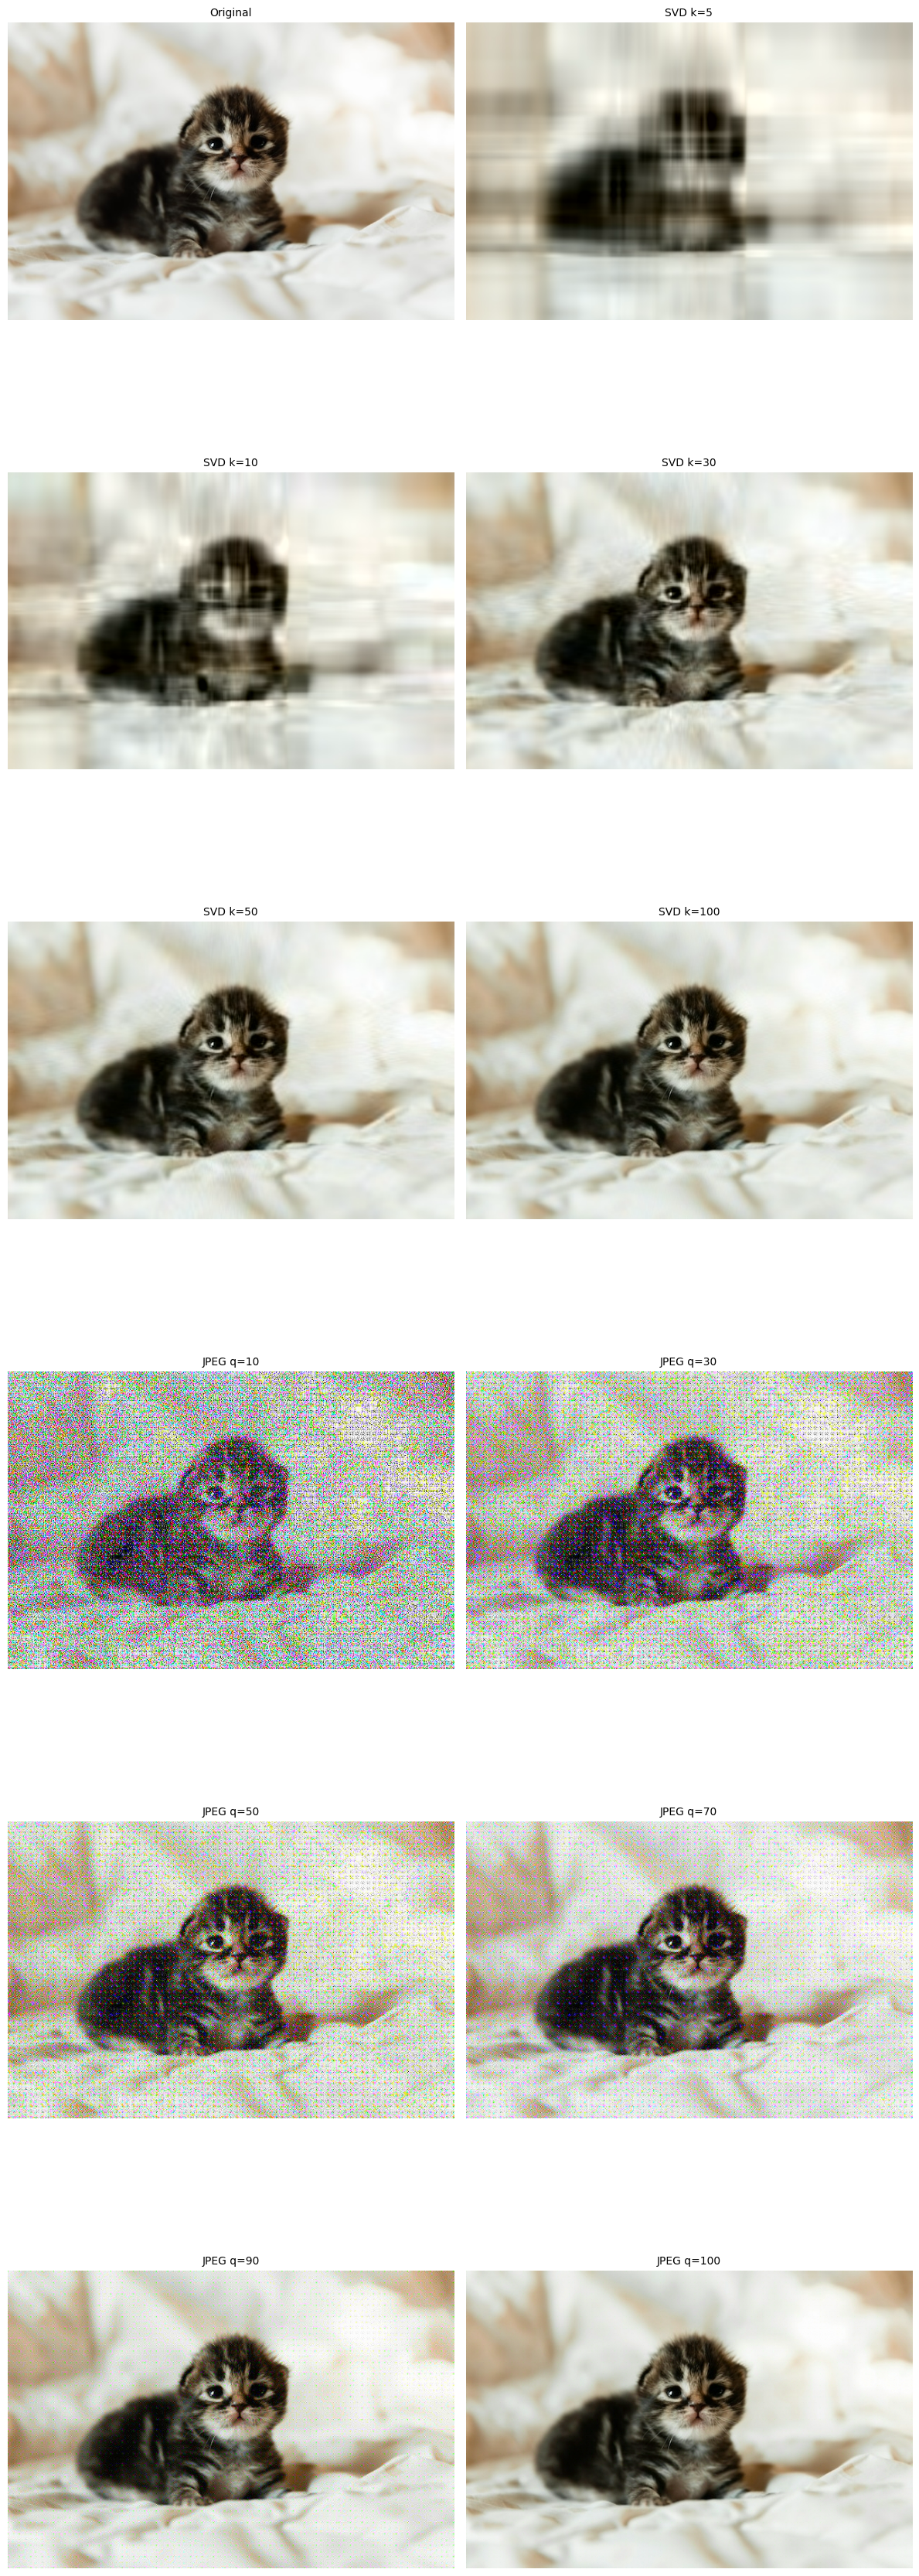

In [14]:
import cv2
images = [('ava.bmp', 'Original')]
images += [(f'temp_svd_k{k}.bmp', f'SVD k={k}') for k in [5, 10, 30, 50, 100]]
images += [(f'temp_jpeg_q{q}.bmp', f'JPEG q={q}') for q in [10, 30, 50, 70, 90, 100]]

ncols = 2
nrows = (len(images) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6 * nrows))
axes = axes.flatten() if nrows > 1 else [axes]

for i, (path, title) in enumerate(images):
    img = cv2.imread(path)
    if img is not None and i < len(axes):
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(title, fontsize=10)
        axes[i].axis('off')

for j in range(len(images), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()